# Setting kinematical attenuation from DWBA

This notebook answers two practical questions for the RuO$_2$/TiO$_2$
example:

1. How should the empirical `SXRDCrystal.atten` parameter be set
   when a kinematical CTR is compared with DWBA?
2. For a fixed-incidence rod, above which exit angle
   $\alpha_{f,\min}$ and reciprocal coordinate $L_{\min}$ is that one-number
   attenuation reliable?

The calculation adapts the attenuation diagnostic from the final section of
`pt100_dwba_ctr_example.ipynb`. It loads
`RuO2_TiO2_Poisson_etching.xtal` and explicitly sets both the
surface roughness and RuO$_2$/TiO$_2$ interfacial width to zero before any
calculation. It uses the non-specular
$(1,1,L)$ rod, and the same incident angles $0.5\alpha_c$ and
$1.5\alpha_c$ used by the DWBA diagnostics tutorial. Angles passed to orGUI
are glancing angles in radians; $L$ is in reference-cell r.l.u.

In [1]:
%matplotlib inline
from pathlib import Path
import copy
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np


def _find_repository_root():
    """Return the checkout containing this example notebook, if available."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "orgui" / "datautils").is_dir():
            return candidate
    return None


repository_root = _find_repository_root()
if repository_root is not None and "orgui" not in sys.modules:
    sys.path.insert(0, str(repository_root))

from orgui.datautils.xrayutils import CTRcalc, CTRutil
from orgui.datautils.xrayutils.CTRoptics import homogeneous_bulk_profile


def _find_example_file(filename):
    """Find an example beside the notebook or from the repository root."""
    candidates = [Path(filename), Path("examples/CTR") / filename]
    if repository_root is not None:
        candidates.append(repository_root / "examples" / "CTR" / filename)
    for candidate in candidates:
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(filename)


ANGLE_BATCH_SIZE = 30


def _batch_slices(size):
    """Yield slices that fit within the DWBA unique-angle field cache."""
    for start in range(0, size, ANGLE_BATCH_SIZE):
        yield slice(start, min(start + ANGLE_BATCH_SIZE, size))


plt.rcParams.update({"figure.dpi": 115, "axes.grid": True})

## What `atten` means

The kinematical semi-infinite bulk is summed as

$$
F_{\mathrm{bulk}}(L)=
\frac{F_{\mathrm{uc}}(L)}
{1-\exp[-2\pi i L_{\mathrm{bulk}}-\eta]},
\qquad \eta\equiv\mathrm{atten}.
$$

Thus `atten` is a **dimensionless amplitude-decay exponent per
reference-cell out-of-plane repeat**. It is not an intensity scale and is not
a universal material constant.

DWBA does not need this empirical exponent. Its depth decay is already carried
by the imaginary part of the terminal-medium wavevector. For a physical bulk
repeat $d_\perp$ expressed in the reference-cell convention, the equivalent
kinematical exponents are

$$
\eta_i=d_\perp\,\operatorname{Im} k_{z,b}(\alpha_i),
\qquad
\eta_{\mathrm{exact}}(\alpha_i,\alpha_f)
=d_\perp\left[
\operatorname{Im} k_{z,b}(\alpha_i)
+\operatorname{Im} k_{z,b}(\alpha_f)
\right].
$$

`CTRutil.set_atten_from_dwba(crystal, alpha_i)` stores the
incident-only scalar $\eta_i$ in `crystal.atten`.
`CTRutil.attenuation_from_dwba` is the non-mutating, vectorized
diagnostic used to calculate $\eta_{\mathrm{exact}}$. Supplying the empirical
exponent to a DWBA calculation would double-count absorption.

In [2]:
model_path = _find_example_file("RuO2_TiO2_Poisson_etching.xtal")
model_template = CTRcalc.SXRDCrystal.fromFile(model_path)

# Use a sharp structural model: W_surface = W_interface = 0.
surface = model_template["RuO2surface"]
surface.profile = CTRcalc.PoissonProfile(
    mean_change=0.0,
    alpha=float(surface.basis[1]),
    offset=float(surface.basis[2]),
)
surface.basis[:] = (
    surface.profile.mean_change,
    surface.profile.alpha,
    surface.profile.offset,
)

interface = model_template["TiO2toRuO2"]
interface.profile = CTRcalc.SkellamProfile(
    width=0.0,
    asymmetry=float(interface.basis[1]),
)
interface.basis[0] = interface.profile.width
interface.basis[1] = interface.profile.asymmetry
model_template.apply_stacking()

bulk_profile = homogeneous_bulk_profile(model_template.uc_bulk)
delta_substrate = float(bulk_profile.delta[0])
alpha_c = float(np.sqrt(2.0 * delta_substrate))

layered_profile = model_template.stratified_optical_profile()
delta_dense = float(np.max(layered_profile.delta))
alpha_c_dense = float(np.sqrt(2.0 * delta_dense))

ROD = (1.0, 1.0)
INCIDENT_FACTORS = (0.5, 1.5)
RELATIVE_EXIT_TOLERANCE = 0.05
L_MAX = 5.0

print(
    f"model: {model_path}\n"
    f"energy: {model_template.uc_bulk._E * 1e-3:g} keV\n"
    f"surface W: {surface.profile.mean_change:g}\n"
    f"interfacial W: {interface.profile.width:g}\n"
    f"serialized empirical atten: {model_template.atten:.6g}\n"
    f"TiO2 substrate alpha_c: {np.rad2deg(alpha_c):.6f} deg\n"
    f"densest-layer alpha_c: {np.rad2deg(alpha_c_dense):.6f} deg\n"
    f"rod: ({ROD[0]:g}, {ROD[1]:g}, L)"
)

model: RuO2_TiO2_Poisson_etching.xtal
energy: 20 keV
surface W: 0
interfacial W: 0
serialized empirical atten: 0.01
TiO2 substrate alpha_c: 0.116012 deg
densest-layer alpha_c: 0.143385 deg
rod: (1, 1, L)


## Turning an exit-angle tolerance into $L_{\min}$

At fixed $\alpha_i$, the scalar approximation omits only the exit-path part of
the attenuation. This notebook calls it reliable when

$$
\frac{\eta_{\mathrm{exact}}-\eta_i}{\eta_i}
=\frac{\eta_f}{\eta_i}\leq\epsilon,
\qquad \epsilon=0.05.
$$

The first exit angle satisfying this criterion is
$\alpha_{f,\min}$. The measured-angle DWBA geometry maps that angle to
$L_{\min}$ on the selected rod. This criterion tests attenuation bookkeeping;
it does not assert that Fresnel transmission, Yoneda enhancement,
four-channel interference, polarization, or refraction have become negligible.

In [3]:
# Resolve both the critical-angle region and the high-L CTR oscillations.
alpha_f_scan = np.unique(
    np.concatenate(
        (
            np.geomspace(
                np.deg2rad(0.002), np.deg2rad(1.0),
                1200, endpoint=False,
            ),
            np.linspace(
                np.deg2rad(1.0), np.deg2rad(35.0), 3600
            ),
        )
    )
)
attenuation_cases = {}

for factor in INCIDENT_FACTORS:
    model = copy.deepcopy(model_template)
    alpha_i = factor * alpha_c
    serialized_atten = float(model.atten)

    atten_incident = CTRutil.set_atten_from_dwba(model, alpha_i)
    atten_exact = CTRutil.attenuation_from_dwba(
        model, alpha_i, alpha_f_scan
    )

    L_batches = []
    for batch in _batch_slices(alpha_f_scan.size):
        prepared = model.dwba.prepare_from_glancing(
            ROD[0], ROD[1], alpha_i, alpha_f_scan[batch]
        )
        L_batches.append(np.asarray(prepared.hkl[2], dtype=np.float64))
    L = np.concatenate(L_batches)

    relative_exit = (atten_exact - atten_incident) / atten_incident
    good = relative_exit <= RELATIVE_EXIT_TOLERANCE
    first_good = int(np.flatnonzero(good)[0])

    attenuation_cases[factor] = {
        "model": model,
        "alpha_i": alpha_i,
        "alpha_f": alpha_f_scan,
        "L": L,
        "serialized_atten": serialized_atten,
        "atten_incident": atten_incident,
        "atten_exact": atten_exact,
        "relative_exit": relative_exit,
        "first_good": first_good,
        "alpha_f_min": alpha_f_scan[first_good],
        "L_min": L[first_good],
    }

    print(
        f"\nalpha_i = {factor:g} alpha_c "
        f"= {np.rad2deg(alpha_i):.6f} deg\n"
        f"  incident-only atten = {atten_incident:.8g}\n"
        f"  alpha_f,min = "
        f"{np.rad2deg(alpha_f_scan[first_good]):.6f} deg\n"
        f"  L_min = {L[first_good]:.8g}\n"
        f"  exit/incident attenuation at cutoff = "
        f"{relative_exit[first_good]:.3%}"
    )


alpha_i = 0.5 alpha_c = 0.058006 deg
  incident-only atten = 0.11695922
  alpha_f,min = 0.116575 deg
  L_min = 0.032345243
  exit/incident attenuation at cutoff = 4.937%



alpha_i = 1.5 alpha_c = 0.174018 deg
  incident-only atten = 0.00055526789
  alpha_f,min = 2.606002 deg
  L_min = 0.51489725
  exit/incident attenuation at cutoff = 4.984%


Text(0.5, 0.98, 'DWBA-equivalent attenuation for RuO$_2$/TiO$_2$')

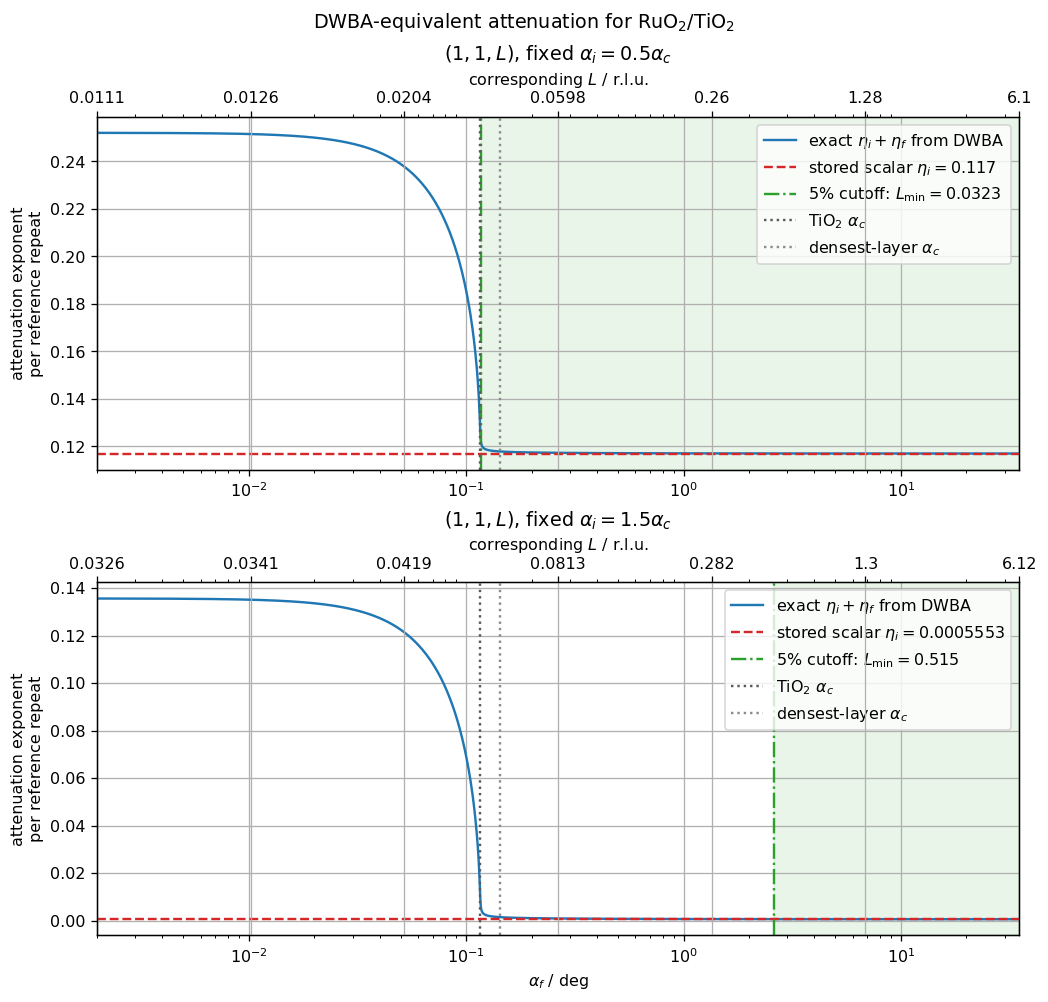

In [4]:
figure, axes = plt.subplots(
    len(INCIDENT_FACTORS), 1,
    figsize=(9.0, 4.3 * len(INCIDENT_FACTORS)),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for axis, factor in zip(axes, INCIDENT_FACTORS):
    case = attenuation_cases[factor]
    alpha_f_degrees = np.rad2deg(case["alpha_f"])
    cutoff_degrees = np.rad2deg(case["alpha_f_min"])

    axis.semilogx(
        alpha_f_degrees, case["atten_exact"], color="C0",
        label=r"exact $\eta_i+\eta_f$ from DWBA",
    )
    axis.axhline(
        case["atten_incident"], color="C3", linestyle="--",
        label=rf"stored scalar $\eta_i={case['atten_incident']:.4g}$",
    )
    axis.axvline(
        cutoff_degrees, color="C2", linestyle="-.",
        label=rf"5% cutoff: $L_{{\min}}={case['L_min']:.3g}$",
    )
    axis.axvspan(
        cutoff_degrees, alpha_f_degrees[-1],
        color="C2", alpha=0.10,
    )
    axis.axvline(
        np.rad2deg(alpha_c), color="0.35", linestyle=":",
        label=r"TiO$_2$ $\alpha_c$",
    )
    axis.axvline(
        np.rad2deg(alpha_c_dense), color="0.55", linestyle=":",
        label=r"densest-layer $\alpha_c$",
    )
    axis.set_xlim(alpha_f_degrees[0], alpha_f_degrees[-1])
    axis.set_ylabel("attenuation exponent\nper reference repeat")
    axis.set_title(
        rf"$(1,1,L)$, fixed $\alpha_i={factor:g}\alpha_c$"
    )
    axis.legend(loc="upper right")

    top_axis = axis.twiny()
    top_axis.set_xscale(axis.get_xscale())
    top_axis.set_xlim(axis.get_xlim())
    angle_ticks = np.geomspace(
        case["alpha_f"][0], case["alpha_f"][-1], 7
    )
    top_axis.set_xticks(np.rad2deg(angle_ticks))
    top_axis.set_xticklabels(
        [
            f"{value:.3g}"
            for value in np.interp(
                angle_ticks, case["alpha_f"], case["L"]
            )
        ]
    )
    top_axis.set_xlabel(r"corresponding $L$ / r.l.u.")

axes[-1].set_xlabel(r"$\alpha_f$ / deg")
figure.suptitle(
    "DWBA-equivalent attenuation for RuO$_2$/TiO$_2$"
)

## Effect on the kinematical CTR

A fixed-incidence kinematical model has only one stored
`crystal.atten`. The curves below compare that incident-only scalar
with a diagnostic calculation that changes `atten` point by point to
the exact $\eta_i+\eta_f$. The shaded region is below the cutoff derived
above.

Agreement between these two curves means the scalar attenuation is adequate.
It does **not** mean that the kinematical structure factor reproduces a full
DWBA intensity. Near structural minima, even a small attenuation mismatch can
be amplified by coherent cancellation between the bulk, sharp interface,
film, and terminating surface amplitudes.

In [5]:
kinematical_cases = {}

for factor, case in attenuation_cases.items():
    selected = (case["L"] >= 0.0) & (case["L"] <= L_MAX)
    L = case["L"][selected]
    atten_exact = case["atten_exact"][selected]
    model = case["model"]
    h = np.full_like(L, ROD[0])
    k = np.full_like(L, ROD[1])

    model.atten = float(case["atten_incident"])
    F_scalar = model.F(h, k, L)

    F_exact = np.empty_like(F_scalar, dtype=np.complex128)
    for index, atten_value in enumerate(atten_exact):
        model.atten = float(atten_value)
        F_exact[index] = model.F(
            h[index:index + 1],
            k[index:index + 1],
            L[index:index + 1],
        )[0]
    model.atten = float(case["atten_incident"])

    intensity_scalar = np.abs(F_scalar) ** 2
    intensity_exact = np.abs(F_exact) ** 2
    relative_intensity_error = np.abs(
        intensity_scalar - intensity_exact
    ) / np.maximum(intensity_exact, np.finfo(np.float64).tiny)

    kinematical_cases[factor] = {
        "L": L,
        "intensity_scalar": intensity_scalar,
        "intensity_exact": intensity_exact,
        "relative_intensity_error": relative_intensity_error,
    }

Text(0.5, 0.98, 'One scalar attenuation versus angle-dependent attenuation on $(1,1,L)$')

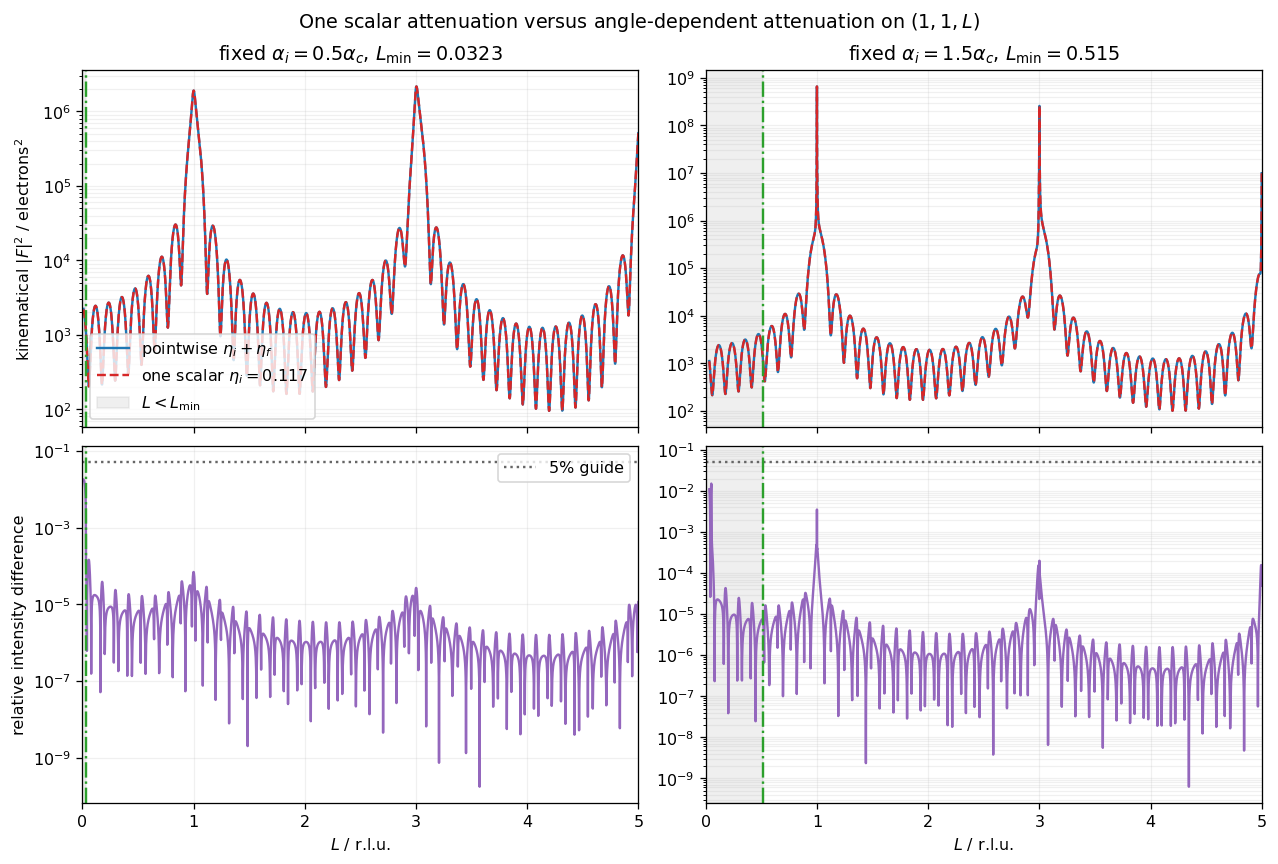

In [6]:
figure, axes = plt.subplots(
    2, len(INCIDENT_FACTORS), figsize=(11.0, 7.4),
    sharex="col", constrained_layout=True, squeeze=False,
)

for column, factor in enumerate(INCIDENT_FACTORS):
    case = attenuation_cases[factor]
    curves = kinematical_cases[factor]
    L = curves["L"]

    axes[0, column].semilogy(
        L, curves["intensity_exact"], color="C0",
        label=r"pointwise $\eta_i+\eta_f$",
    )
    axes[0, column].semilogy(
        L, curves["intensity_scalar"], "--", color="C3",
        label=rf"one scalar $\eta_i={case['atten_incident']:.4g}$",
    )
    axes[1, column].semilogy(
        L, curves["relative_intensity_error"], color="C4",
    )
    axes[1, column].axhline(
        RELATIVE_EXIT_TOLERANCE, color="0.4", linestyle=":",
        label="5% guide",
    )

    for row in range(2):
        axes[row, column].axvspan(
            0.0, case["L_min"], color="0.5", alpha=0.12,
            label=r"$L<L_{\min}$" if row == 0 else None,
        )
        axes[row, column].axvline(
            case["L_min"], color="C2", linestyle="-.",
        )
        axes[row, column].set_xlim(0.0, L_MAX)
        axes[row, column].grid(alpha=0.18, which="both")

    axes[0, column].set_title(
        rf"fixed $\alpha_i={factor:g}\alpha_c$, "
        rf"$L_{{\min}}={case['L_min']:.3g}$"
    )
    axes[1, column].set_xlabel(r"$L$ / r.l.u.")

axes[0, 0].set_ylabel(r"kinematical $|F|^2$ / electrons$^2$")
axes[1, 0].set_ylabel("relative intensity difference")
axes[0, 0].legend(loc="lower left")
axes[1, 0].legend(loc="upper right")
figure.suptitle(
    r"One scalar attenuation versus angle-dependent attenuation on $(1,1,L)$"
)

In [7]:
summary = [
    "## Numerical answer for this RuO$_2$/TiO$_2$ model",
    "",
    "| fixed incidence | atten $=\\eta_i$ | "
    "$\\alpha_{f,\\min}$ | $L_{\\min}$ | scalar range |",
    "|---:|---:|---:|---:|---:|",
]
for factor in INCIDENT_FACTORS:
    case = attenuation_cases[factor]
    summary.append(
        f"| $\\alpha_i={factor:g}\\alpha_c$ "
        f"({np.rad2deg(case['alpha_i']):.4f} deg) "
        f"| {case['atten_incident']:.6g} "
        f"| {np.rad2deg(case['alpha_f_min']):.4f} deg "
        f"| {case['L_min']:.4f} "
        f"| $L\\geq {case['L_min']:.4f}$ |"
    )
display(Markdown("\n".join(summary)))

## Numerical answer for this RuO$_2$/TiO$_2$ model

| fixed incidence | atten $=\eta_i$ | $\alpha_{f,\min}$ | $L_{\min}$ | scalar range |
|---:|---:|---:|---:|---:|
| $\alpha_i=0.5\alpha_c$ (0.0580 deg) | 0.116959 | 0.1166 deg | 0.0323 | $L\geq 0.0323$ |
| $\alpha_i=1.5\alpha_c$ (0.1740 deg) | 0.000555268 | 2.6060 deg | 0.5149 | $L\geq 0.5149$ |

## How to use the result

For a kinematical rod measured at one fixed incidence angle:

1. Set the amplitude attenuation with
   `CTRutil.set_atten_from_dwba(crystal, alpha_i)`.
2. Choose a tolerance $\epsilon$ for the omitted exit path and calculate
   `CTRutil.attenuation_from_dwba(crystal, alpha_i, alpha_f)`.
3. Convert the first $\alpha_f$ satisfying
   $\eta_f/\eta_i\leq\epsilon$ into $L_{\min}$ using the same measured-angle
   geometry as the rod. Use the scalar model only for $L\geq L_{\min}$.
4. Below that cutoff, use angle-dependent attenuation point by point or use
   DWBA.

This is a **necessary attenuation criterion, not a complete kinematical
validity criterion**. If either beam is near or below a critical angle, a bare
kinematical intensity still omits the distorted incident/exit fields. In
particular, the small $L_{\min}$ at $0.5\alpha_c$ occurs because the
incident-path attenuation is already large; it does not make the subcritical
incident field kinematical. Kinematical curves also do not reproduce
polarization contraction, refraction shifts, Yoneda features, or dynamical
Bragg scattering.

For specular scans $\alpha_i=\alpha_f$ changes continuously, so there is no
single fixed-incidence plateau valid over the complete scan. Use the
angle-dependent attenuation or the DWBA observable instead.